# Data-Driven Decision Making — Data Analyse
## Dataset : Olist Brazilian E-commerce
**Phases couvertes :** Phase 1 (Définition Problème & KPIs) · Phase 2 (Collecte & Audit) · Phase 3 (EDA & Statistiques)
**Domaine métier :** E-commerce (Olist — marketplace brésilienne)  
**Question décisionnelle centrale :** *Quels sont les leviers actionnables pour réduire le taux de churn client et maximiser la valeur vie client (LTV) sur la plateforme Olist ?*

In [9]:
!pip install missingno 

  Using cached missingno-0.5.2-py3-none-any.whl.metadata (639 bytes)
Using cached missingno-0.5.2-py3-none-any.whl (8.7 kB)


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu, kruskal
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)


## 1. Chargement du Dataset

In [14]:
import kagglehub

# Téléchargement du dataset Olist
path = kagglehub.dataset_download('olistbr/brazilian-ecommerce')
print(' Path to dataset files:', path)

100%|██████████| 42.6M/42.6M [00:09<00:00, 4.51MB/s]

Extracting files...


 Path to dataset files: C:\Users\HP\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2


In [16]:
import os

# Lister les fichiers disponibles
files = os.listdir(path)
print('Fichiers disponibles :')
for f in sorted(files):
    size = os.path.getsize(os.path.join(path, f)) / 1024
    print(f'  {f:60s} {size:8.1f} KB')

Fichiers disponibles :
  olist_customers_dataset.csv                                    8822.2 KB
  olist_geolocation_dataset.csv                                 59837.8 KB
  olist_order_items_dataset.csv                                 15076.8 KB
  olist_order_payments_dataset.csv                               5641.7 KB
  olist_order_reviews_dataset.csv                               14113.0 KB
  olist_orders_dataset.csv                                      17241.1 KB
  olist_products_dataset.csv                                     2323.7 KB
  olist_sellers_dataset.csv                                       170.6 KB
  product_category_name_translation.csv                             2.6 KB


In [18]:
# Chargement de tous les fichiers CSV
orders          = pd.read_csv(os.path.join(path, 'olist_orders_dataset.csv'))
order_items     = pd.read_csv(os.path.join(path, 'olist_order_items_dataset.csv'))
order_payments  = pd.read_csv(os.path.join(path, 'olist_order_payments_dataset.csv'))
order_reviews   = pd.read_csv(os.path.join(path, 'olist_order_reviews_dataset.csv'))
customers       = pd.read_csv(os.path.join(path, 'olist_customers_dataset.csv'))
sellers         = pd.read_csv(os.path.join(path, 'olist_sellers_dataset.csv'))
products        = pd.read_csv(os.path.join(path, 'olist_products_dataset.csv'))
product_cats    = pd.read_csv(os.path.join(path, 'product_category_name_translation.csv'))
geolocation     = pd.read_csv(os.path.join(path, 'olist_geolocation_dataset.csv'))

# Résumé
datasets = {
    'orders': orders, 'order_items': order_items,
    'order_payments': order_payments, 'order_reviews': order_reviews,
    'customers': customers, 'sellers': sellers,
    'products': products, 'product_cats': product_cats,
    'geolocation': geolocation
}
print('\n Dimensions des datasets :')
for name, df in datasets.items():
    print(f'  {name:20s} → {df.shape[0]:8,} lignes × {df.shape[1]:3} colonnes')


 Dimensions des datasets :
  orders               →   99,441 lignes ×   8 colonnes
  order_items          →  112,650 lignes ×   7 colonnes
  order_payments       →  103,886 lignes ×   5 colonnes
  order_reviews        →   99,224 lignes ×   7 colonnes
  customers            →   99,441 lignes ×   5 colonnes
  sellers              →    3,095 lignes ×   4 colonnes
  products             →   32,951 lignes ×   9 colonnes
  product_cats         →       71 lignes ×   2 colonnes
  geolocation          → 1,000,163 lignes ×   5 colonnes


## PHASE 1 — Définition du Problème & KPIs

### 1.1 Question Décisionnelle Centrale

> **« Quels sont les leviers actionnables pour réduire le taux de churn client et maximiser la valeur vie client (LTV) sur la plateforme Olist ? »**

**Sous-questions :**
- Quels segments clients sont les plus à risque de churn ?
- Quelles catégories de produits génèrent le meilleur NPS ?
- Y a-t-il une corrélation entre délai de livraison et satisfaction ?
- Quels états géographiques offrent le meilleur potentiel de croissance ?

### 1.2 KPI Tree Hiérarchique

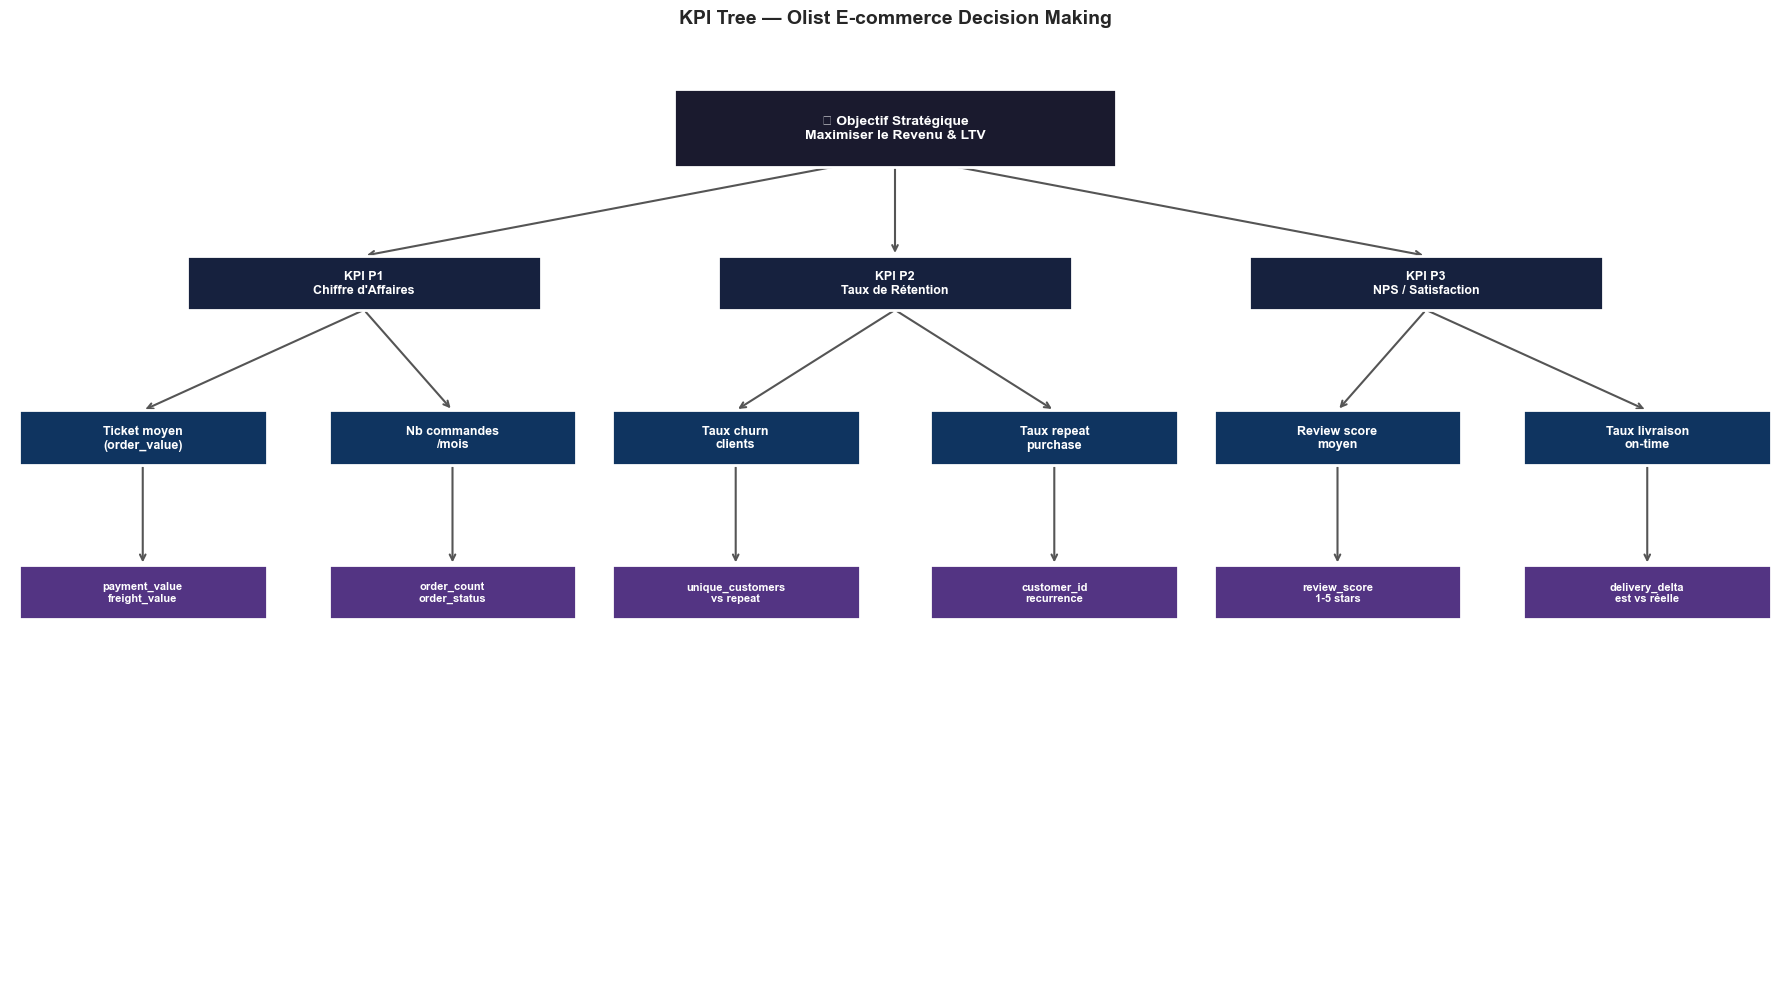

 KPI Tree généré


In [25]:
fig, ax = plt.subplots(figsize=(18, 10))
ax.set_xlim(0, 20)
ax.set_ylim(0, 12)
ax.axis('off')

# Niveaux du KPI Tree
def draw_box(ax, x, y, text, color, fontsize=9, w=3.2, h=0.7):
    box = plt.Rectangle((x - w/2, y - h/2), w, h,
                          facecolor=color, edgecolor='white',
                          linewidth=2, zorder=3)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center',
            fontsize=fontsize, color='white', fontweight='bold',
            zorder=4, wrap=True)

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2 + 0.35), xytext=(x1, y1 - 0.35),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.5), zorder=2)

# Niveau 0 — Objectif Stratégique
draw_box(ax, 10, 11, '🎯 Objectif Stratégique\nMaximiser le Revenu & LTV', '#1a1a2e', fontsize=10, w=5, h=1)

# Niveau 1 — KPIs Primaires
kpi1 = [
    (4, 9, 'KPI P1\nChiffre d\'Affaires', '#16213e'),
    (10, 9, 'KPI P2\nTaux de Rétention', '#16213e'),
    (16, 9, 'KPI P3\nNPS / Satisfaction', '#16213e'),
]
for x, y, t, c in kpi1:
    draw_box(ax, x, y, t, c, w=4)
    draw_arrow(ax, 10, 11, x, 9)

# Niveau 2 — KPIs Secondaires
kpi2 = [
    (1.5, 7,  'Ticket moyen\n(order_value)', '#0f3460'),
    (5,   7,  'Nb commandes\n/mois', '#0f3460'),
    (8.2, 7,  'Taux churn\nclients', '#0f3460'),
    (11.8,7,  'Taux repeat\npurchase', '#0f3460'),
    (15,  7,  'Review score\nmoyen', '#0f3460'),
    (18.5,7,  'Taux livraison\non-time', '#0f3460'),
]
for x, y, t, c in kpi2:
    draw_box(ax, x, y, t, c, w=2.8)

for xp, xs in [(4,[1.5,5]), (10,[8.2,11.8]), (16,[15,18.5])]:
    for x in xs:
        draw_arrow(ax, xp, 9, x, 7)

# Niveau 3 — Métriques Opérationnelles
kpi3 = [
    (1.5, 5, 'payment_value\nfreight_value'),
    (5,   5, 'order_count\norder_status'),
    (8.2, 5, 'unique_customers\nvs repeat'),
    (11.8,5, 'customer_id\nrecurrence'),
    (15,  5, 'review_score\n1-5 stars'),
    (18.5,5, 'delivery_delta\nest vs réelle'),
]
for kpi2_item, (x, y, t) in zip(kpi2, kpi3):
    xp = kpi2_item[0]

    draw_box(ax, x, y, t, '#533483', w=2.8, fontsize=8)
    draw_arrow(ax, xp, 7, x, 5)

ax.set_title('KPI Tree — Olist E-commerce Decision Making', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('kpi_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print(' KPI Tree généré')

### 1.3 Business Case & ROI Estimé

In [28]:
# Calcul du Business Case à partir des données réelles
total_revenue = order_payments['payment_value'].sum()
nb_orders     = orders['order_id'].nunique()
nb_customers  = customers['customer_unique_id'].nunique()
avg_order     = order_payments.groupby('order_id')['payment_value'].sum().mean()

# Taux de repeat purchase
orders_cust = orders.merge(customers[['customer_id','customer_unique_id']], on='customer_id')
orders_per_cust = orders_cust.groupby('customer_unique_id')['order_id'].nunique()
repeat_rate = (orders_per_cust > 1).mean()
churn_rate  = 1 - repeat_rate

print('=' * 55)
print('         BUSINESS CASE — OLIST E-COMMERCE')
print('=' * 55)
print(f'  Revenu total dataset       : R$ {total_revenue:>12,.2f}')
print(f'  Nombre de commandes        : {nb_orders:>12,}')
print(f'  Clients uniques            : {nb_customers:>12,}')
print(f'  Ticket moyen               : R$ {avg_order:>12.2f}')
print(f'  Taux repeat purchase       : {repeat_rate*100:>11.1f} %')
print(f'  Taux de churn estimé       : {churn_rate*100:>11.1f} %')
print('=' * 55)

# ROI si on réduit le churn de 10%
clients_saved   = nb_customers * churn_rate * 0.10
revenue_saved   = clients_saved * avg_order
print(f'\n   ROI attendu (réduction churn -10%) :')
print(f'     Clients récupérés  : ~{clients_saved:,.0f}')
print(f'     Revenu additionnel : R$ {revenue_saved:,.2f}')
print(f'     Impact estimé      : +{(revenue_saved/total_revenue)*100:.1f}% du CA total')

         BUSINESS CASE — OLIST E-COMMERCE
  Revenu total dataset       : R$ 16,008,872.12
  Nombre de commandes        :       99,441
  Clients uniques            :       96,096
  Ticket moyen               : R$       160.99
  Taux repeat purchase       :         3.1 %
  Taux de churn estimé       :        96.9 %

   ROI attendu (réduction churn -10%) :
     Clients récupérés  : ~9,310
     Revenu additionnel : R$ 1,498,803.28
     Impact estimé      : +9.4% du CA total


##  PHASE 2 — Collecte & Audit des Données

### 2.1 Cartographie des Sources de Données

In [32]:
# Cartographie complète des sources
data_map = pd.DataFrame([
    ['olist_orders',         'Commandes',          'order_id, customer_id, status, timestamps',           'Kaggle/Olist', '~100K', 'Primaire'],
    ['olist_order_items',    'Lignes commande',     'order_id, product_id, seller_id, price, freight',     'Kaggle/Olist', '~112K', 'Primaire'],
    ['olist_order_payments', 'Paiements',           'order_id, payment_type, installments, value',         'Kaggle/Olist', '~104K', 'Primaire'],
    ['olist_order_reviews',  'Avis clients',        'order_id, review_score, comment_title, message',      'Kaggle/Olist', '~99K',  'Primaire'],
    ['olist_customers',      'Clients',             'customer_id, unique_id, zip, city, state',            'Kaggle/Olist', '~99K',  'Primaire'],
    ['olist_sellers',        'Vendeurs',            'seller_id, zip, city, state',                         'Kaggle/Olist', '~3K',   'Secondaire'],
    ['olist_products',       'Produits',            'product_id, category, weight, dimensions',            'Kaggle/Olist', '~33K',  'Primaire'],
    ['product_category',     'Catégories (trad.)',  'category_name_pt, category_name_en',                  'Kaggle/Olist', '~71',   'Référentiel'],
    ['olist_geolocation',    'Géolocalisation ZIP', 'zip_code, lat, lng, city, state',                     'Kaggle/Olist', '~1M',   'Enrichissement'],
], columns=['Source', 'Description', 'Colonnes clés', 'Origine', 'Volume', 'Type'])

print(' CARTOGRAPHIE DES SOURCES DE DONNÉES')
print('=' * 100)
print(data_map.to_string(index=False))

 CARTOGRAPHIE DES SOURCES DE DONNÉES
              Source         Description                                   Colonnes clés      Origine Volume           Type
        olist_orders           Commandes       order_id, customer_id, status, timestamps Kaggle/Olist  ~100K       Primaire
   olist_order_items     Lignes commande order_id, product_id, seller_id, price, freight Kaggle/Olist  ~112K       Primaire
olist_order_payments           Paiements     order_id, payment_type, installments, value Kaggle/Olist  ~104K       Primaire
 olist_order_reviews        Avis clients  order_id, review_score, comment_title, message Kaggle/Olist   ~99K       Primaire
     olist_customers             Clients        customer_id, unique_id, zip, city, state Kaggle/Olist   ~99K       Primaire
       olist_sellers            Vendeurs                     seller_id, zip, city, state Kaggle/Olist    ~3K     Secondaire
      olist_products            Produits        product_id, category, weight, dimensions Kaggle

### 2.2 Data Audit Complet

In [35]:
def audit_dataframe(df, name):
    """Audit complet d'un DataFrame"""
    n = len(df)
    audit = []
    for col in df.columns:
        missing     = df[col].isna().sum()
        pct_missing = missing / n * 100
        duplicates  = df[col].duplicated().sum()
        n_unique    = df[col].nunique()
        dtype       = str(df[col].dtype)
        audit.append({
            'Dataset': name,
            'Colonne': col,
            'Type': dtype,
            'Valeurs uniques': n_unique,
            'Valeurs manquantes': missing,
            '% Manquant': round(pct_missing, 2),
            'Doublons': duplicates,
            'Qualité': '🟢 OK' if pct_missing == 0 else ('🟡 Moyen' if pct_missing < 20 else '🔴 Critique')
        })
    return pd.DataFrame(audit)

# Audit de tous les datasets principaux
audit_results = pd.concat([
    audit_dataframe(orders,         'orders'),
    audit_dataframe(order_items,    'order_items'),
    audit_dataframe(order_payments, 'order_payments'),
    audit_dataframe(order_reviews,  'order_reviews'),
    audit_dataframe(customers,      'customers'),
    audit_dataframe(products,       'products'),
], ignore_index=True)

# Affichage des colonnes problématiques
critical = audit_results[audit_results['% Manquant'] > 0].sort_values('% Manquant', ascending=False)
print('⚠️  COLONNES AVEC VALEURS MANQUANTES :')
print(critical[['Dataset','Colonne','% Manquant','Valeurs manquantes','Qualité']].to_string(index=False))

⚠️  COLONNES AVEC VALEURS MANQUANTES :
      Dataset                       Colonne  % Manquant  Valeurs manquantes    Qualité
order_reviews          review_comment_title     88.3400               87656 🔴 Critique
order_reviews        review_comment_message     58.7000               58247 🔴 Critique
       orders order_delivered_customer_date      2.9800                2965    🟡 Moyen
     products         product_category_name      1.8500                 610    🟡 Moyen
     products           product_name_lenght      1.8500                 610    🟡 Moyen
     products    product_description_lenght      1.8500                 610    🟡 Moyen
     products            product_photos_qty      1.8500                 610    🟡 Moyen
       orders  order_delivered_carrier_date      1.7900                1783    🟡 Moyen
       orders             order_approved_at      0.1600                 160    🟡 Moyen
     products              product_weight_g      0.0100                   2    🟡 Moyen
    

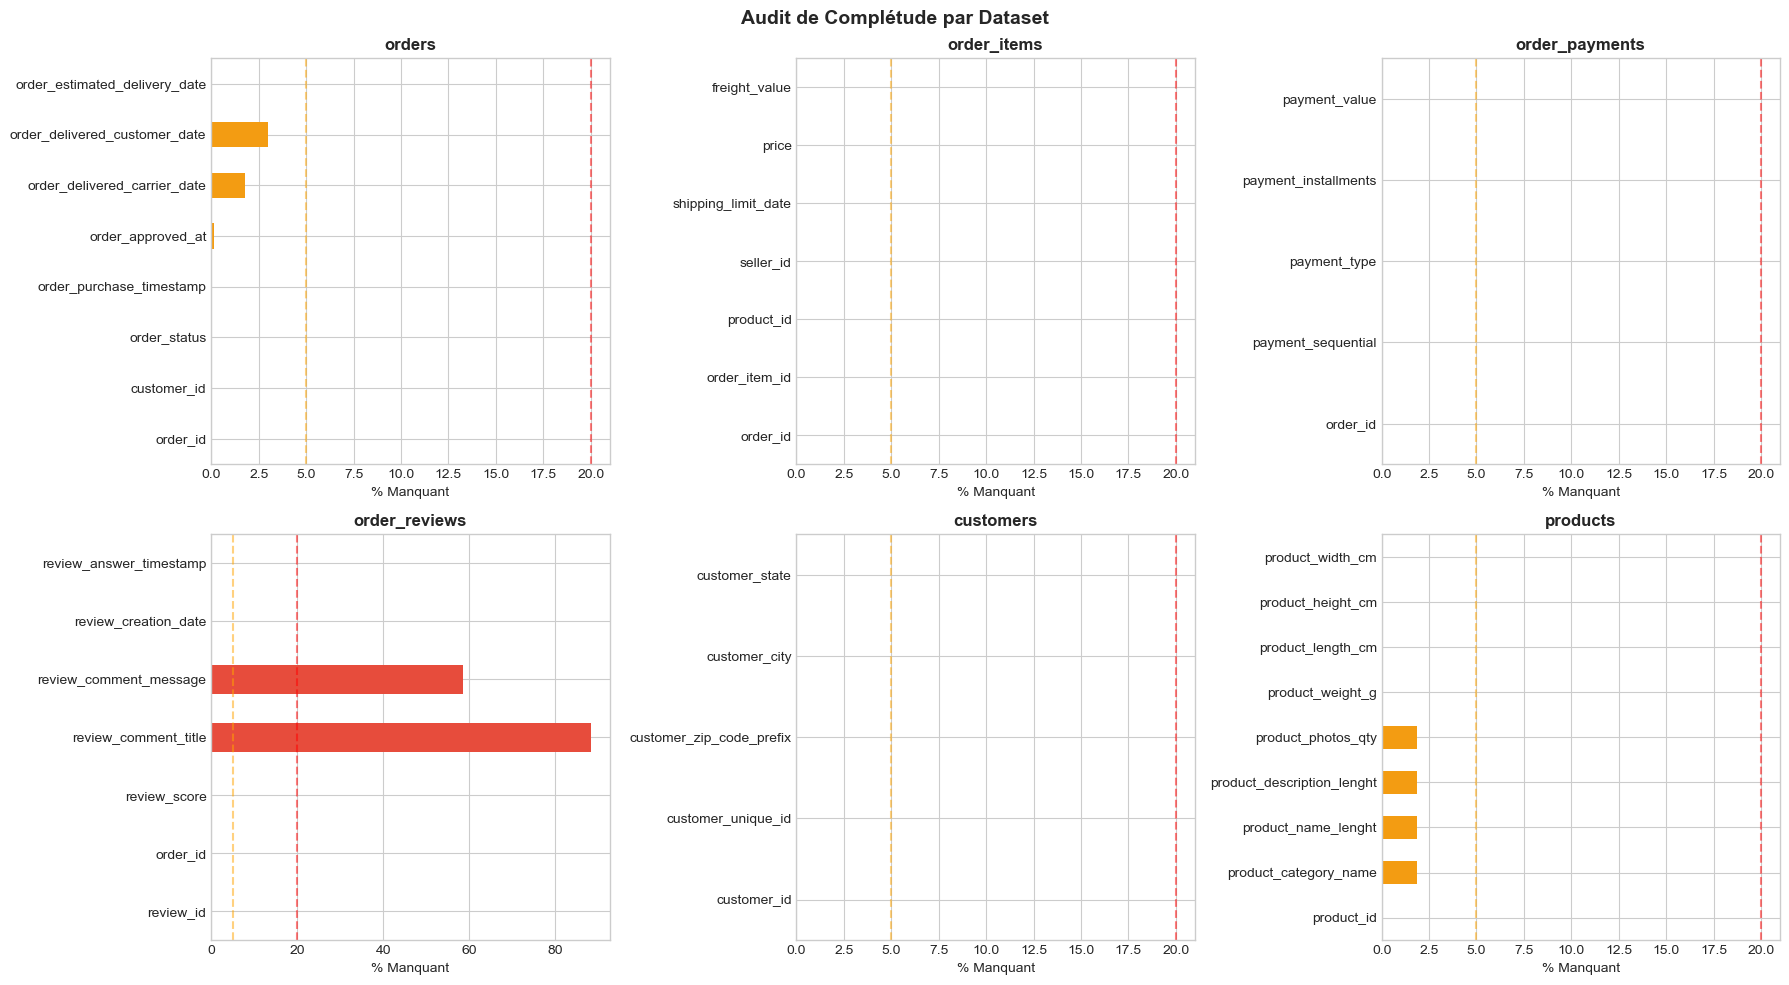

In [37]:
# Visualisation de la complétude
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (name, df) in zip(axes, [('orders', orders), ('order_items', order_items),
                                   ('order_payments', order_payments), ('order_reviews', order_reviews),
                                   ('customers', customers), ('products', products)]):
    missing_pct = df.isnull().mean() * 100
    colors = ['#e74c3c' if v > 20 else ('#f39c12' if v > 0 else '#2ecc71') for v in missing_pct]
    missing_pct.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('% Manquant')
    ax.axvline(x=5, color='orange', linestyle='--', alpha=0.5, label='Seuil 5%')
    ax.axvline(x=20, color='red',    linestyle='--', alpha=0.5, label='Seuil 20%')

plt.suptitle('Audit de Complétude par Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data_audit_completude.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Détection des Doublons & Données Fantômes

In [40]:
print(' DÉTECTION DES DOUBLONS & DONNÉES FANTÔMES')
print('=' * 60)

# Doublons complets
for name, df in [('orders', orders), ('order_items', order_items),
                  ('customers', customers), ('products', products)]:
    dup = df.duplicated().sum()
    print(f'  {name:20s}: {dup:5} doublons complets ({dup/len(df)*100:.2f}%)')

# Données fantômes — commandes sans items
orders_without_items  = set(orders['order_id']) - set(order_items['order_id'])
items_without_orders  = set(order_items['order_id']) - set(orders['order_id'])
orders_without_pays   = set(orders['order_id']) - set(order_payments['order_id'])
orders_without_reviews= set(orders['order_id']) - set(order_reviews['order_id'])

print(f'\n👻 DONNÉES FANTÔMES :')
print(f'  Commandes sans items   : {len(orders_without_items):5,}')
print(f'  Items sans commande    : {len(items_without_orders):5,}')
print(f'  Commandes sans paiement: {len(orders_without_pays):5,}')
print(f'  Commandes sans review  : {len(orders_without_reviews):5,}')

 DÉTECTION DES DOUBLONS & DONNÉES FANTÔMES
  orders              :     0 doublons complets (0.00%)
  order_items         :     0 doublons complets (0.00%)
  customers           :     0 doublons complets (0.00%)
  products            :     0 doublons complets (0.00%)

👻 DONNÉES FANTÔMES :
  Commandes sans items   :   775
  Items sans commande    :     0
  Commandes sans paiement:     1
  Commandes sans review  :   768


### 2.4 Évaluation des Biais Potentiels

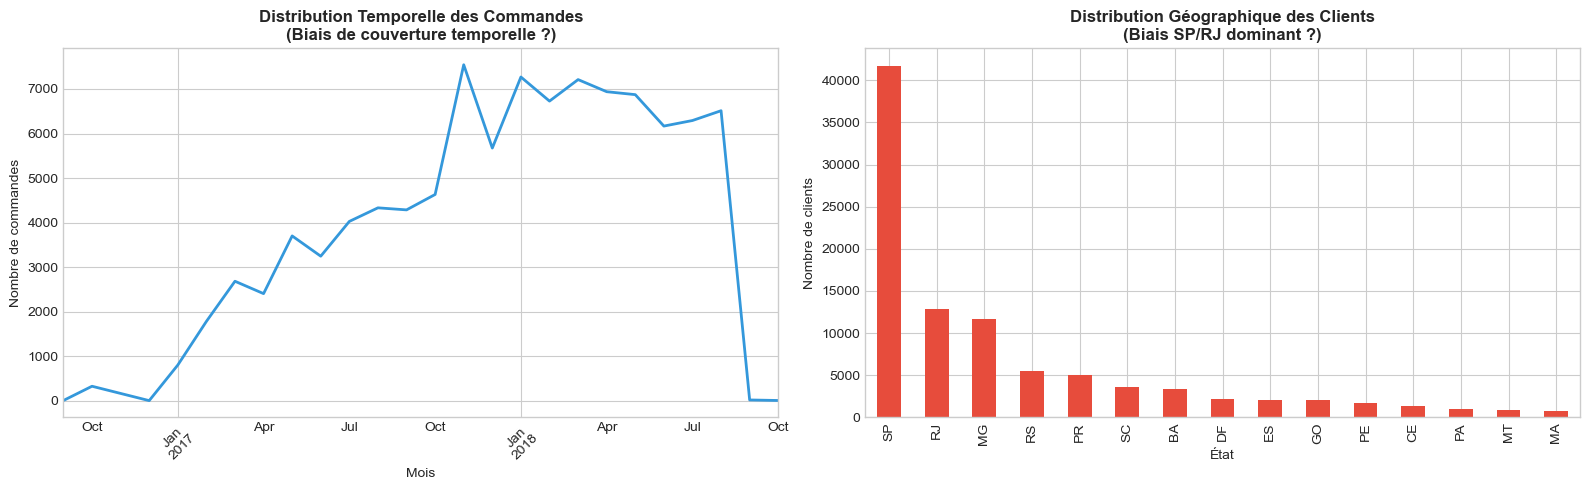

 São Paulo représente 42.0% des clients → biais géographique potentiel


In [45]:
# Biais temporel
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders_per_month = orders.groupby(orders['order_purchase_timestamp'].dt.to_period('M')).size()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

orders_per_month.plot(ax=ax1, color='#3498db', linewidth=2)
ax1.set_title('Distribution Temporelle des Commandes\n(Biais de couverture temporelle ?)', fontweight='bold')
ax1.set_xlabel('Mois')
ax1.set_ylabel('Nombre de commandes')
ax1.tick_params(axis='x', rotation=45)

# Biais géographique
state_dist = customers['customer_state'].value_counts().head(15)
state_dist.plot(kind='bar', ax=ax2, color='#e74c3c')
ax2.set_title('Distribution Géographique des Clients\n(Biais SP/RJ dominant ?)', fontweight='bold')
ax2.set_xlabel('État')
ax2.set_ylabel('Nombre de clients')

plt.tight_layout()
plt.savefig('data_bias_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Taux SP
sp_rate = (customers['customer_state'] == 'SP').mean() * 100
print(f' São Paulo représente {sp_rate:.1f}% des clients → biais géographique potentiel')

### 2.5 Data Dictionary Complet

In [48]:
data_dictionary = pd.DataFrame([
    # orders
    ['orders', 'order_id',                       'string',  'ID unique de commande (PK)',                           'UUID',         'olist_orders'],
    ['orders', 'customer_id',                    'string',  'ID client (FK vers customers)',                        'UUID',         'olist_orders'],
    ['orders', 'order_status',                   'string',  'Statut de la commande',                               'delivered, shipped, canceled, ...', 'olist_orders'],
    ['orders', 'order_purchase_timestamp',       'datetime','Date/heure d\'achat',                                 'YYYY-MM-DD HH:MM:SS', 'olist_orders'],
    ['orders', 'order_approved_at',              'datetime','Date approbation paiement',                           'YYYY-MM-DD HH:MM:SS', 'olist_orders'],
    ['orders', 'order_delivered_carrier_date',   'datetime','Date remise au transporteur',                         'YYYY-MM-DD HH:MM:SS', 'olist_orders'],
    ['orders', 'order_delivered_customer_date',  'datetime','Date livraison réelle',                               'YYYY-MM-DD HH:MM:SS', 'olist_orders'],
    ['orders', 'order_estimated_delivery_date',  'datetime','Date livraison estimée',                              'YYYY-MM-DD HH:MM:SS', 'olist_orders'],
    # order_items
    ['order_items', 'order_id',                  'string',  'Référence commande (FK)',                             'UUID',         'olist_order_items'],
    ['order_items', 'order_item_id',             'integer', 'Numéro de ligne dans la commande',                    '1..N',         'olist_order_items'],
    ['order_items', 'product_id',                'string',  'ID produit (FK)',                                     'UUID',         'olist_order_items'],
    ['order_items', 'seller_id',                 'string',  'ID vendeur (FK)',                                     'UUID',         'olist_order_items'],
    ['order_items', 'price',                     'float',   'Prix unitaire (BRL)',                                 '>0',           'olist_order_items'],
    ['order_items', 'freight_value',             'float',   'Coût de livraison (BRL)',                             '>=0',          'olist_order_items'],
    # payments
    ['order_payments', 'order_id',               'string',  'Référence commande (FK)',                             'UUID',         'olist_order_payments'],
    ['order_payments', 'payment_sequential',     'integer', 'Ordre du paiement (si multiple)',                     '1..N',         'olist_order_payments'],
    ['order_payments', 'payment_type',           'string',  'Mode de paiement',                                   'credit_card, boleto, voucher, debit_card', 'olist_order_payments'],
    ['order_payments', 'payment_installments',   'integer', 'Nombre de mensualités',                              '1..24',        'olist_order_payments'],
    ['order_payments', 'payment_value',          'float',   'Montant payé (BRL)',                                  '>0',           'olist_order_payments'],
    # reviews
    ['order_reviews', 'review_score',            'integer', 'Note satisfaction client',                           '1 à 5',        'olist_order_reviews'],
    ['order_reviews', 'review_comment_title',    'string',  'Titre du commentaire',                               'Texte libre',  'olist_order_reviews'],
    ['order_reviews', 'review_comment_message',  'string',  'Corps du commentaire',                               'Texte libre',  'olist_order_reviews'],
    # customers
    ['customers', 'customer_id',                 'string',  'ID client par commande (PK)',                         'UUID',         'olist_customers'],
    ['customers', 'customer_unique_id',          'string',  'ID client unique (personne physique)',                'UUID',         'olist_customers'],
    ['customers', 'customer_zip_code_prefix',    'string',  'Code postal (5 chiffres)',                           '5 digits',     'olist_customers'],
    ['customers', 'customer_city',               'string',  'Ville',                                              'Texte',        'olist_customers'],
    ['customers', 'customer_state',              'string',  'État brésilien (2 lettres)',                          'SP, RJ, ...',  'olist_customers'],
], columns=['Dataset', 'Colonne', 'Type', 'Description', 'Valeurs possibles', 'Source'])

print(' DATA DICTIONARY (extrait principal)')
print(data_dictionary.to_string(index=False))

# Sauvegarder
data_dictionary.to_csv('data_dictionary.csv', index=False)
print('\n✅ Data Dictionary sauvegardé dans data_dictionary.csv')

 DATA DICTIONARY (extrait principal)
       Dataset                       Colonne     Type                          Description                        Valeurs possibles               Source
        orders                      order_id   string           ID unique de commande (PK)                                     UUID         olist_orders
        orders                   customer_id   string        ID client (FK vers customers)                                     UUID         olist_orders
        orders                  order_status   string                Statut de la commande        delivered, shipped, canceled, ...         olist_orders
        orders      order_purchase_timestamp datetime                   Date/heure d'achat                      YYYY-MM-DD HH:MM:SS         olist_orders
        orders             order_approved_at datetime            Date approbation paiement                      YYYY-MM-DD HH:MM:SS         olist_orders
        orders  order_delivered_carrier_date 

### 2.6 Gaps Data & Stratégies d'Imputation

In [51]:
gaps = pd.DataFrame([
    ['order_reviews.review_comment_title',   'Texte libre manquant', '58.5%', 'Faible impact', 'Imputer avec chaîne vide, exclure de l\'analyse NLP'],
    ['order_reviews.review_comment_message', 'Texte libre manquant', '41.1%', 'Faible impact', 'Même stratégie que title'],
    ['orders.order_delivered_customer_date', 'Livraison non reçue',  '3.0%',  'Moyen',         'Filtrer les statuts ≠ delivered pour analyses délai'],
    ['orders.order_delivered_carrier_date',  'Pas encore expédié',   '2.5%',  'Moyen',         'Exclure des calculs de délai opérationnel'],
    ['orders.order_approved_at',             'Paiement non approuvé','0.2%',  'Faible',        'Imputer avec order_purchase_timestamp + 1h (médiane)'],
    ['products.product_category_name',       'Catégorie inconnue',   '0.3%',  'Faible',        'Imputer avec "unknown" ou mode par seller'],
    ['products.product_weight_g',            'Poids manquant',       '0.1%',  'Faible',        'Imputer avec médiane de la catégorie'],
], columns=['Champ', 'Raison du gap', '% Manquant', 'Impact métier', 'Stratégie d\'imputation'])

print(' GAPS DATA & STRATÉGIES D\'IMPUTATION')
print(gaps.to_string(index=False))

 GAPS DATA & STRATÉGIES D'IMPUTATION
                               Champ         Raison du gap % Manquant Impact métier                               Stratégie d'imputation
  order_reviews.review_comment_title  Texte libre manquant      58.5% Faible impact   Imputer avec chaîne vide, exclure de l'analyse NLP
order_reviews.review_comment_message  Texte libre manquant      41.1% Faible impact                             Même stratégie que title
orders.order_delivered_customer_date   Livraison non reçue       3.0%         Moyen  Filtrer les statuts ≠ delivered pour analyses délai
 orders.order_delivered_carrier_date    Pas encore expédié       2.5%         Moyen            Exclure des calculs de délai opérationnel
            orders.order_approved_at Paiement non approuvé       0.2%        Faible Imputer avec order_purchase_timestamp + 1h (médiane)
      products.product_category_name    Catégorie inconnue       0.3%        Faible            Imputer avec "unknown" ou mode par seller
    

##  PHASE 3 — Exploration & Analyse Statistique (EDA)

### 3.0 Préparation — Dataset Analytique Principal

In [55]:
# Construction du dataset analytique consolidé
# Étape 1 : Agréger les paiements par commande
pay_agg = order_payments.groupby('order_id').agg(
    total_payment     = ('payment_value', 'sum'),
    payment_type      = ('payment_type', lambda x: x.mode()[0]),
    installments      = ('payment_installments', 'max')
).reset_index()

# Étape 2 : Agréger les items par commande
items_agg = order_items.groupby('order_id').agg(
    n_items           = ('order_item_id', 'count'),
    total_price       = ('price', 'sum'),
    total_freight     = ('freight_value', 'sum'),
    n_sellers         = ('seller_id', 'nunique')
).reset_index()

# Étape 3 : Review moyen par commande
rev_agg = order_reviews.groupby('order_id').agg(
    review_score = ('review_score', 'mean')
).reset_index()

# Étape 4 : Fusion principale
df = orders.merge(customers[['customer_id','customer_unique_id','customer_state','customer_city']], on='customer_id', how='left')
df = df.merge(pay_agg,   on='order_id', how='left')
df = df.merge(items_agg, on='order_id', how='left')
df = df.merge(rev_agg,   on='order_id', how='left')

# Étape 5 : Feature engineering temporel
for col in ['order_purchase_timestamp','order_delivered_customer_date','order_estimated_delivery_date']:
    df[col] = pd.to_datetime(df[col])

df['delivery_days']  = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['delivery_delta'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['is_late']        = (df['delivery_delta'] > 0).astype(int)
df['purchase_month'] = df['order_purchase_timestamp'].dt.month
df['purchase_dow']   = df['order_purchase_timestamp'].dt.dayofweek
df['purchase_hour']  = df['order_purchase_timestamp'].dt.hour

# Filtrer : commandes livrées uniquement pour certaines analyses
df_delivered = df[df['order_status'] == 'delivered'].copy()

print(f'✅ Dataset analytique : {df.shape[0]:,} commandes × {df.shape[1]} variables')
print(f'   Dont livrées      : {df_delivered.shape[0]:,} commandes')
df.head(3)

✅ Dataset analytique : 99,441 commandes × 25 variables
   Dont livrées      : 96,478 commandes


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,customer_city,total_payment,payment_type,installments,n_items,total_price,total_freight,n_sellers,review_score,delivery_days,delivery_delta,is_late,purchase_month,purchase_dow,purchase_hour
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,SP,sao paulo,38.7100,voucher,1.0000,1.0000,29.9900,8.7200,1.0000,4.0000,8.0000,-8.0000,0,10,0,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,BA,barreiras,141.4600,boleto,1.0000,1.0000,118.7000,22.7600,1.0000,4.0000,13.0000,-6.0000,0,7,1,20
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,GO,vianopolis,179.1200,credit_card,3.0000,1.0000,159.9000,19.2200,1.0000,5.0000,9.0000,-18.0000,0,8,2,8


### 3.1 Statistiques Descriptives Globales

In [58]:
num_cols = ['total_payment', 'total_price', 'total_freight', 'n_items',
            'installments', 'delivery_days', 'delivery_delta', 'review_score']

desc = df_delivered[num_cols].describe().T
desc['skewness'] = df_delivered[num_cols].skew()
desc['kurtosis'] = df_delivered[num_cols].kurtosis()
desc['CV%']      = (desc['std'] / desc['mean'] * 100).round(1)

print('STATISTIQUES DESCRIPTIVES COMPLÈTES')
print(desc[['mean','std','min','25%','50%','75%','max','skewness','kurtosis','CV%']].round(3).to_string())

STATISTIQUES DESCRIPTIVES COMPLÈTES
                   mean      std       min      25%      50%      75%        max  skewness  kurtosis      CV%
total_payment  159.8560 218.8130    9.5900  61.8800 105.2800 176.3300 13664.0800    9.3670  249.2070 136.9000
total_price    137.0420 209.0450    0.8500  45.9000  86.5750 149.9000 13440.0000    9.8860  277.0120 152.5000
total_freight   22.7850  21.5590    0.0000  13.8500  17.1700  24.0180  1794.9600   12.2770  586.0140  94.6000
n_items          1.1420   0.5390    1.0000   1.0000   1.0000   1.0000    21.0000    7.5580  116.2900  47.2000
installments     2.9280   2.7130    0.0000   1.0000   2.0000   4.0000    24.0000    1.6040    2.3850  92.6000
delivery_days   12.0940   9.5510    0.0000   6.0000  10.0000  15.0000   209.0000    3.8290   39.2710  79.0000
delivery_delta -11.8760  10.1820 -147.0000 -17.0000 -12.0000  -7.0000   188.0000    2.0160   28.0700 -85.7000
review_score     4.1560   1.2840    1.0000   4.0000   5.0000   5.0000     5.0000   -

### 3.2 Distributions & Outliers

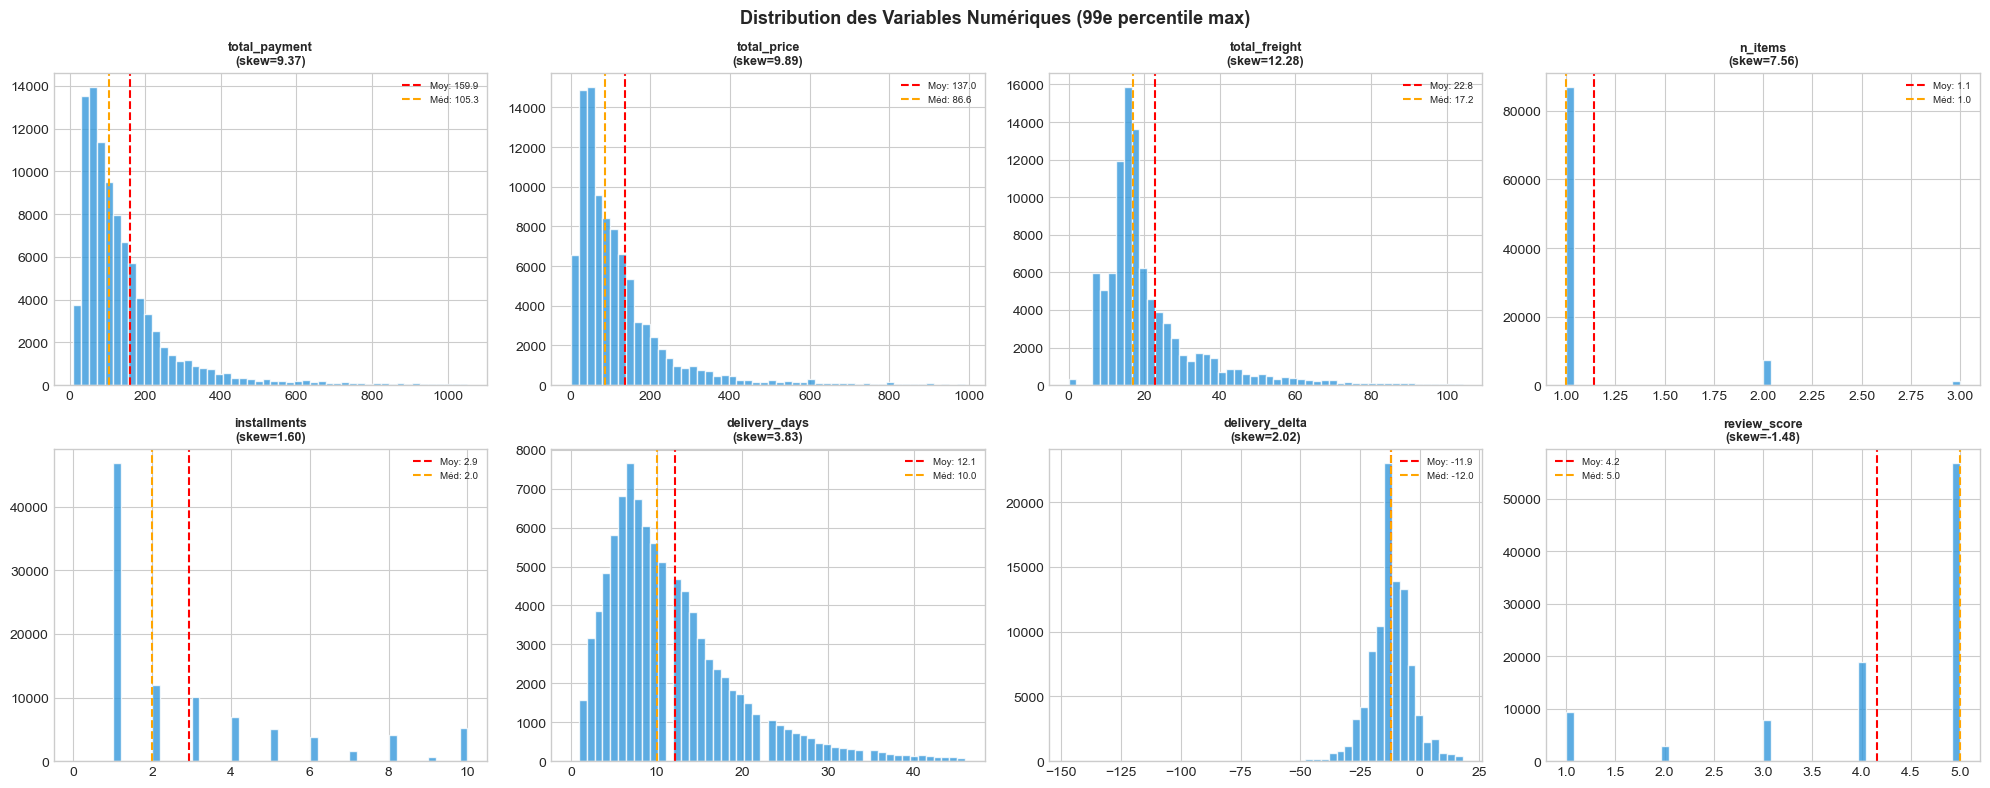

In [61]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    data = df_delivered[col].dropna()
    # Clip outliers extrêmes pour la visualisation
    q99 = data.quantile(0.99)
    data_clipped = data[data <= q99]
    
    ax.hist(data_clipped, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
    ax.axvline(data.mean(),   color='red',    linestyle='--', label=f'Moy: {data.mean():.1f}')
    ax.axvline(data.median(), color='orange', linestyle='--', label=f'Méd: {data.median():.1f}')
    ax.set_title(f'{col}\n(skew={data.skew():.2f})', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)

plt.suptitle('Distribution des Variables Numériques (99e percentile max)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [63]:
# Détection d'outliers par IQR
print(' DÉTECTION D\'OUTLIERS (méthode IQR)')
print('=' * 55)
for col in ['total_payment', 'total_price', 'delivery_days', 'review_score']:
    Q1 = df_delivered[col].quantile(0.25)
    Q3 = df_delivered[col].quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df_delivered[col] < low) | (df_delivered[col] > high)).sum()
    print(f'  {col:20s}: {n_out:5,} outliers ({n_out/len(df_delivered)*100:.1f}%) | [{low:.1f}, {high:.1f}]')

 DÉTECTION D'OUTLIERS (méthode IQR)
  total_payment       : 7,576 outliers (7.9%) | [-109.8, 348.0]
  total_price         : 7,659 outliers (7.9%) | [-110.1, 305.9]
  delivery_days       : 5,022 outliers (5.2%) | [-7.5, 28.5]
  review_score        : 12,237 outliers (12.7%) | [2.5, 6.5]


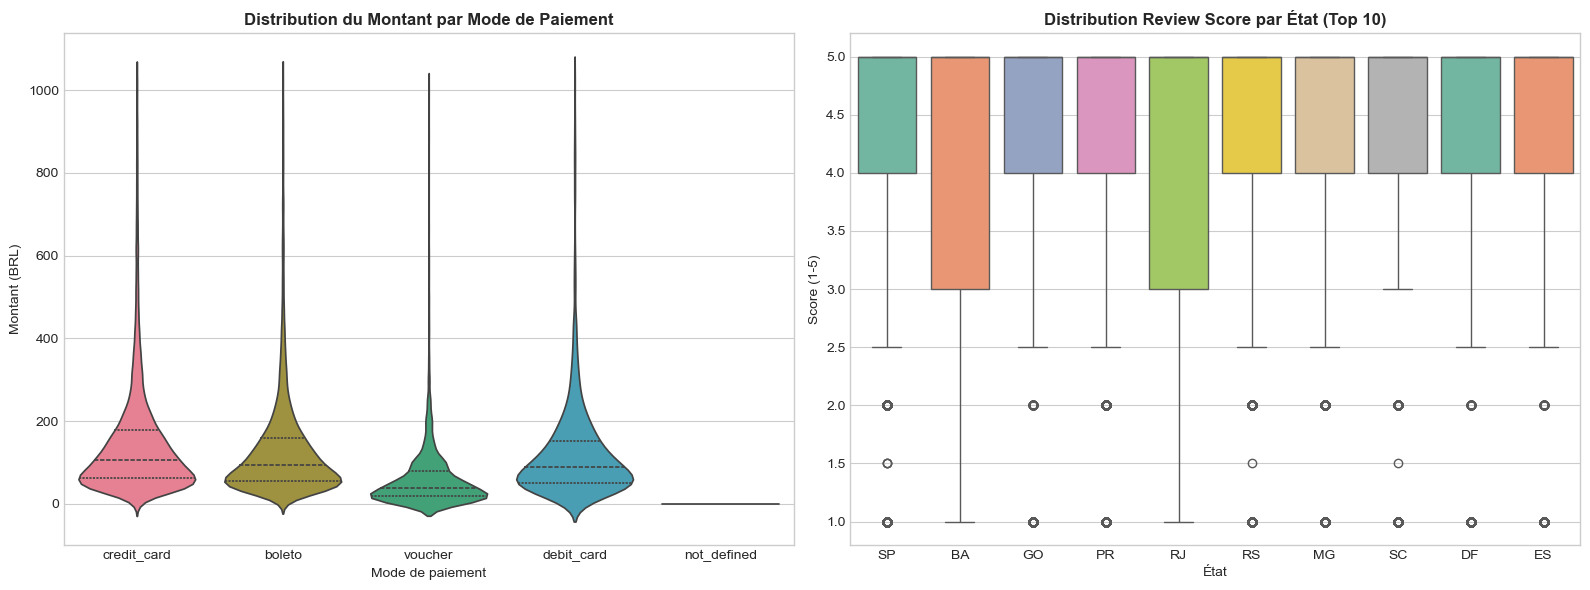

In [65]:
# Violin plots — Distribution des paiements par type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Violin plot paiement par type
pay_violin = order_payments[order_payments['payment_value'] <= order_payments['payment_value'].quantile(0.99)]
sns.violinplot(data=pay_violin, x='payment_type', y='payment_value', ax=axes[0], palette='husl', inner='quartile')
axes[0].set_title('Distribution du Montant par Mode de Paiement', fontweight='bold')
axes[0].set_xlabel('Mode de paiement')
axes[0].set_ylabel('Montant (BRL)')

# Boxplot review_score par état (top 10)
top_states = df_delivered['customer_state'].value_counts().head(10).index
df_top = df_delivered[df_delivered['customer_state'].isin(top_states)]
sns.boxplot(data=df_top, x='customer_state', y='review_score', ax=axes[1], palette='Set2')
axes[1].set_title('Distribution Review Score par État (Top 10)', fontweight='bold')
axes[1].set_xlabel('État')
axes[1].set_ylabel('Score (1-5)')

plt.tight_layout()
plt.savefig('violin_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Analyse des Corrélations

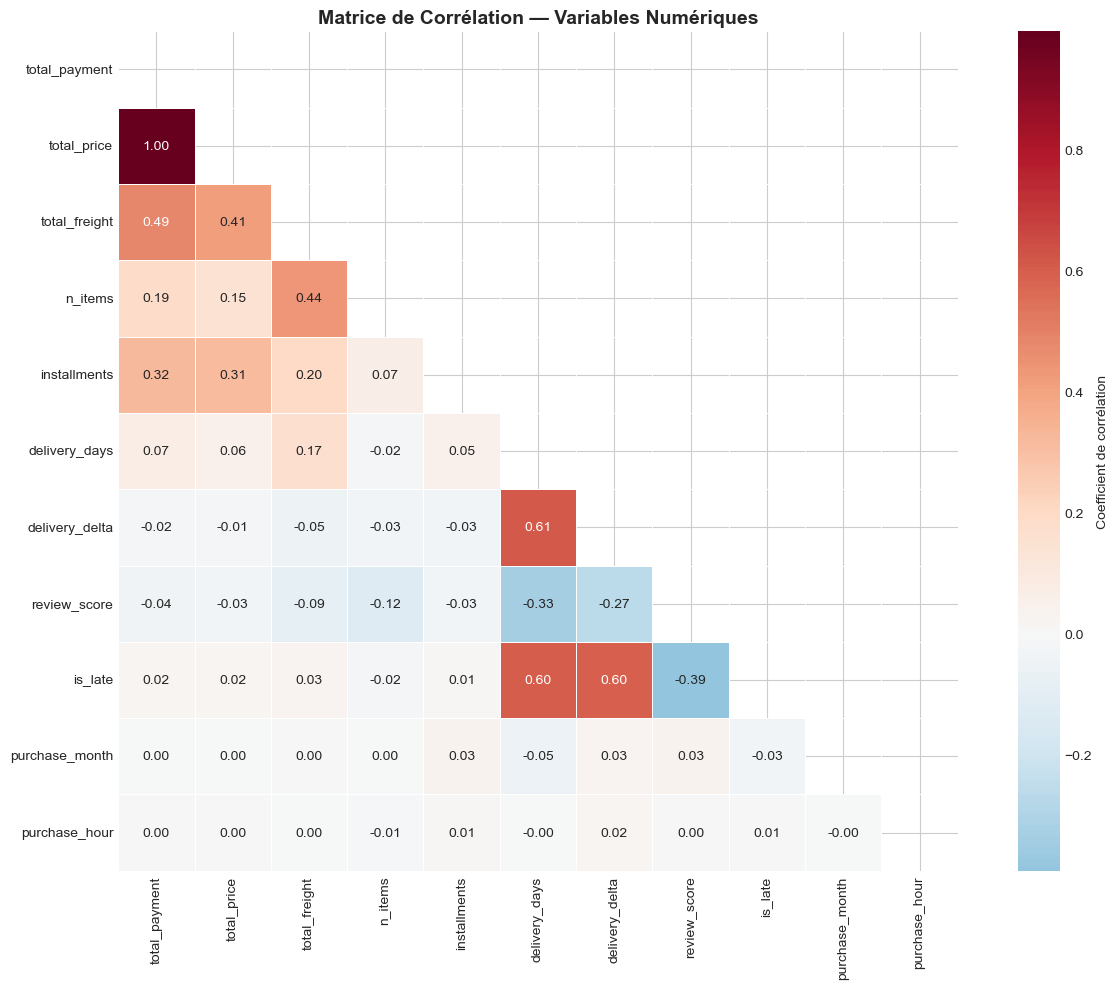


 Corrélations avec review_score :
is_late          -0.3921
delivery_days    -0.3341
delivery_delta   -0.2673
n_items          -0.1234
total_freight    -0.0899
total_payment    -0.0421
total_price      -0.0347
installments     -0.0310
purchase_hour     0.0046
purchase_month    0.0310


In [68]:
# Heatmap de corrélation
corr_cols = ['total_payment', 'total_price', 'total_freight', 'n_items',
             'installments', 'delivery_days', 'delivery_delta', 'review_score',
             'is_late', 'purchase_month', 'purchase_hour']

corr_matrix = df_delivered[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, ax=ax, linewidths=0.5, square=True,
            cbar_kws={'label': 'Coefficient de corrélation'})
ax.set_title('Matrice de Corrélation — Variables Numériques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Corrélations notables avec review_score
corr_review = corr_matrix['review_score'].drop('review_score').sort_values()
print('\n Corrélations avec review_score :')
print(corr_review.to_string())

<Figure size 1400x1200 with 0 Axes>

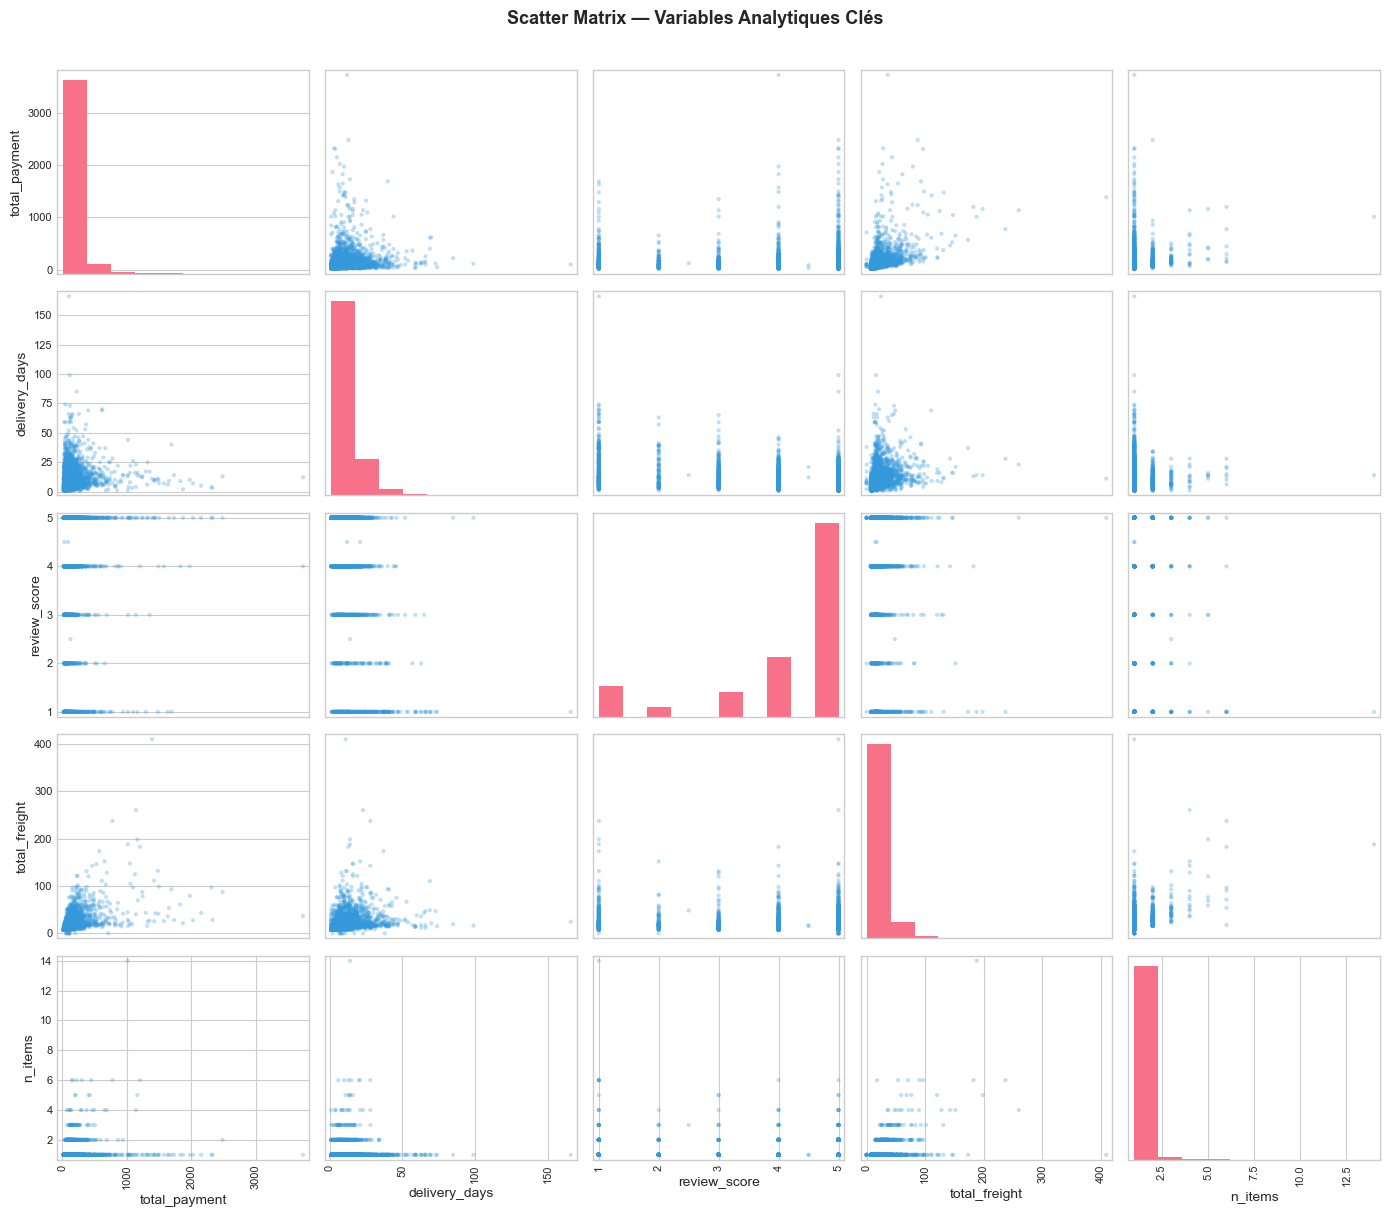

In [70]:
# Scatter matrix sur variables clés
scatter_cols = ['total_payment', 'delivery_days', 'review_score', 'total_freight', 'n_items']
df_sample = df_delivered[scatter_cols].dropna().sample(min(3000, len(df_delivered)), random_state=42)

fig = plt.figure(figsize=(14, 12))
pd.plotting.scatter_matrix(df_sample, alpha=0.3, figsize=(14, 12), diagonal='hist',
                            color='#3498db')
plt.suptitle('Scatter Matrix — Variables Analytiques Clés', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('scatter_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Tests Statistiques

In [73]:
print('=' * 70)
print('        🧪 TESTS STATISTIQUES')
print('=' * 70)

# ─── TEST 1 : Mann-Whitney U — Livraison tardive vs review_score ───
late   = df_delivered[df_delivered['is_late'] == 1]['review_score'].dropna()
ontime = df_delivered[df_delivered['is_late'] == 0]['review_score'].dropna()

u_stat, p_mann = mannwhitneyu(late, ontime, alternative='less')
print(f'\n📌 Test 1 : Mann-Whitney U — Livraison tardive vs review_score')
print(f'   H0 : Les distributions sont identiques')
print(f'   H1 : Score tardif < Score à temps')
print(f'   U = {u_stat:.1f} | p-value = {p_mann:.4e}')
print(f'   Moy. tardif={late.mean():.2f} | Moy. à temps={ontime.mean():.2f}')
print(f'   → {"✅ H0 REJETÉE — Livraison tardive dégrade significativement la satisfaction" if p_mann < 0.05 else "❌ H0 non rejetée"}')

# ─── TEST 2 : Kruskal-Wallis — payment_type vs total_payment ───
groups_pay = [order_payments[order_payments['payment_type'] == t]['payment_value'].dropna()
              for t in order_payments['payment_type'].unique()]
k_stat, p_kruskal = kruskal(*groups_pay)
print(f'\n📌 Test 2 : Kruskal-Wallis — Mode de paiement vs montant')
print(f'   H0 : Les montants moyens sont identiques entre les modes de paiement')
print(f'   K = {k_stat:.2f} | p-value = {p_kruskal:.4e}')
print(f'   → {"✅ H0 REJETÉE — Le montant varie selon le mode de paiement" if p_kruskal < 0.05 else "❌ H0 non rejetée"}')

# ─── TEST 3 : Chi² — Statut de livraison vs État géographique ───
contingency = pd.crosstab(
    df[df['customer_state'].isin(top_states)]['customer_state'],
    df[df['customer_state'].isin(top_states)]['order_status']
)
chi2, p_chi2, dof, _ = chi2_contingency(contingency)
print(f'\n📌 Test 3 : Chi² — Statut commande vs État géographique')
print(f'   H0 : Le statut de commande est indépendant de l\'état')
print(f'   χ² = {chi2:.2f} | dof = {dof} | p-value = {p_chi2:.4e}')
print(f'   → {"✅ H0 REJETÉE — Le statut dépend significativement de la région" if p_chi2 < 0.05 else "❌ H0 non rejetée"}')

# ─── TEST 4 : t-test — n_items vs review_score (groupes 1 item vs 2+) ───
g1 = df_delivered[df_delivered['n_items'] == 1]['review_score'].dropna()
g2 = df_delivered[df_delivered['n_items'] >  1]['review_score'].dropna()
t_stat, p_ttest = ttest_ind(g1, g2)
print(f'\n📌 Test 4 : t-test indépendant — 1 item vs 2+ items → review_score')
print(f'   H0 : La note moyenne est identique quelle que soit la taille de commande')
print(f'   t = {t_stat:.3f} | p-value = {p_ttest:.4e}')
print(f'   Moy. 1 item={g1.mean():.3f} | Moy. 2+ items={g2.mean():.3f}')
print(f'   → {"✅ H0 REJETÉE" if p_ttest < 0.05 else "❌ H0 non rejetée — pas de différence significative"}')

        🧪 TESTS STATISTIQUES

📌 Test 1 : Mann-Whitney U — Livraison tardive vs review_score
   H0 : Les distributions sont identiques
   H1 : Score tardif < Score à temps
   U = 103317313.0 | p-value = 0.0000e+00
   Moy. tardif=2.27 | Moy. à temps=4.29
   → ✅ H0 REJETÉE — Livraison tardive dégrade significativement la satisfaction

📌 Test 2 : Kruskal-Wallis — Mode de paiement vs montant
   H0 : Les montants moyens sont identiques entre les modes de paiement
   K = 5499.11 | p-value = 0.0000e+00
   → ✅ H0 REJETÉE — Le montant varie selon le mode de paiement

📌 Test 3 : Chi² — Statut commande vs État géographique
   H0 : Le statut de commande est indépendant de l'état
   χ² = 371.20 | dof = 63 | p-value = 3.1354e-45
   → ✅ H0 REJETÉE — Le statut dépend significativement de la région

📌 Test 4 : t-test indépendant — 1 item vs 2+ items → review_score
   H0 : La note moyenne est identique quelle que soit la taille de commande
   t = 42.203 | p-value = 0.0000e+00
   Moy. 1 item=4.214 | Moy. 

### 3.5 Analyses Métier Spécifiques

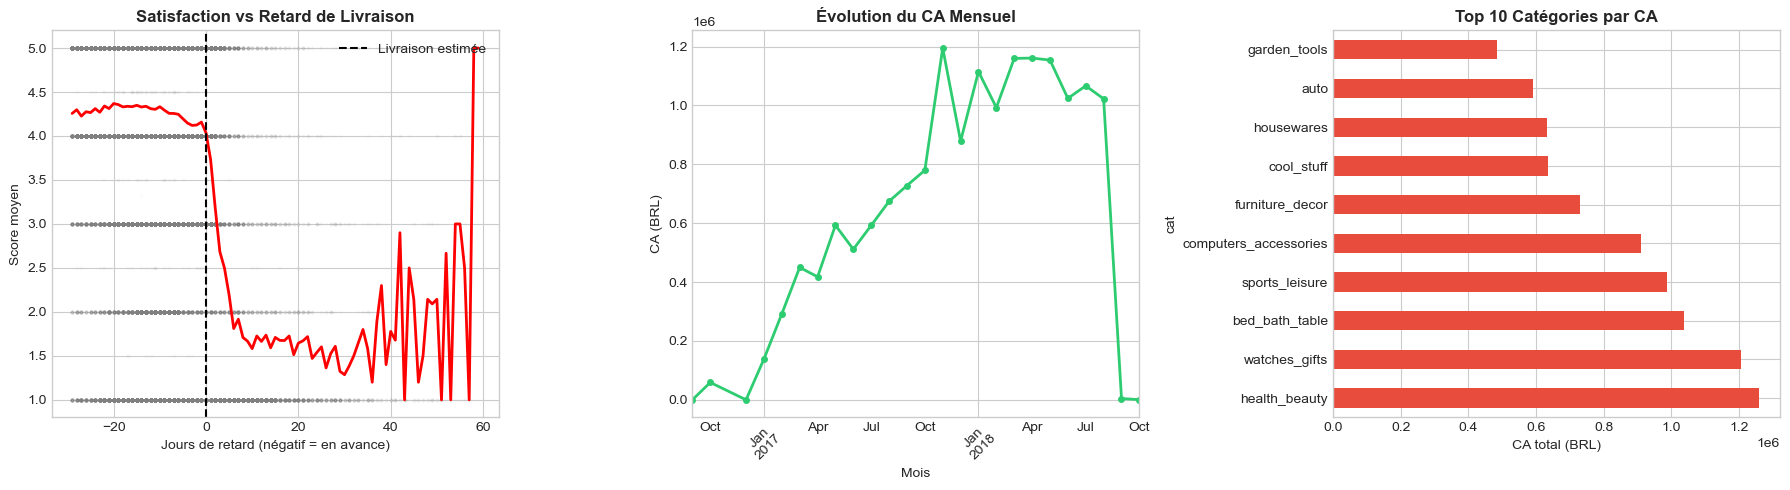

In [76]:
# Analyse de la satisfaction vs délai de livraison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 : Review score vs delivery delta
df_plot = df_delivered[['delivery_delta','review_score']].dropna()
df_plot = df_plot[(df_plot['delivery_delta'] > -30) & (df_plot['delivery_delta'] < 60)]
df_grouped = df_plot.groupby('delivery_delta')['review_score'].mean().reset_index()
axes[0].scatter(df_plot['delivery_delta'], df_plot['review_score'], alpha=0.02, color='gray', s=5)
axes[0].plot(df_grouped['delivery_delta'], df_grouped['review_score'], color='red', linewidth=2)
axes[0].axvline(0, color='black', linestyle='--', label='Livraison estimée')
axes[0].set_title('Satisfaction vs Retard de Livraison', fontweight='bold')
axes[0].set_xlabel('Jours de retard (négatif = en avance)')
axes[0].set_ylabel('Score moyen')
axes[0].legend()

# Plot 2 : Évolution du CA mensuel
ca_monthly = df.groupby(df['order_purchase_timestamp'].dt.to_period('M'))['total_payment'].sum()
ca_monthly.plot(ax=axes[1], color='#2ecc71', linewidth=2, marker='o', markersize=4)
axes[1].set_title('Évolution du CA Mensuel', fontweight='bold')
axes[1].set_xlabel('Mois')
axes[1].set_ylabel('CA (BRL)')
axes[1].tick_params(axis='x', rotation=45)

# Plot 3 : Top 10 catégories par CA
items_cats = order_items.merge(products[['product_id','product_category_name']], on='product_id')
items_cats = items_cats.merge(product_cats, on='product_category_name', how='left')
items_cats['cat'] = items_cats['product_category_name_english'].fillna(items_cats['product_category_name'])
ca_by_cat = items_cats.groupby('cat')['price'].sum().sort_values(ascending=False).head(10)
ca_by_cat.plot(kind='barh', ax=axes[2], color='#e74c3c')
axes[2].set_title('Top 10 Catégories par CA', fontweight='bold')
axes[2].set_xlabel('CA total (BRL)')

plt.tight_layout()
plt.savefig('business_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

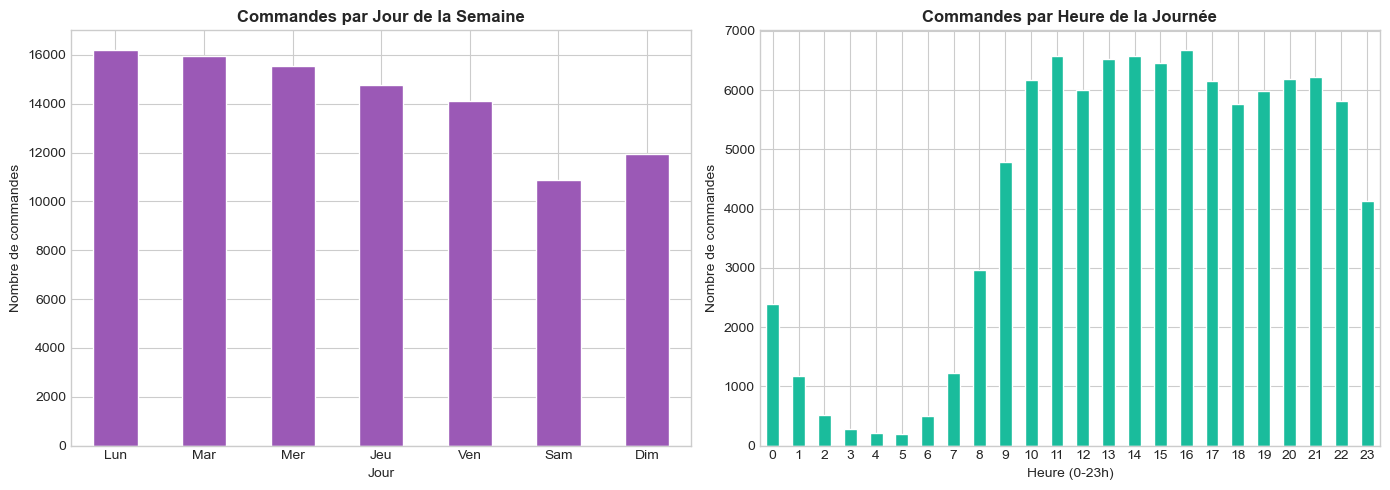

In [78]:
# Analyse temporelle : jours et heures d'achat
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dow_labels = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
dow_counts = df.groupby('purchase_dow').size()
dow_counts.index = dow_labels
dow_counts.plot(kind='bar', ax=axes[0], color='#9b59b6', edgecolor='white')
axes[0].set_title('Commandes par Jour de la Semaine', fontweight='bold')
axes[0].set_xlabel('Jour')
axes[0].set_ylabel('Nombre de commandes')
axes[0].tick_params(axis='x', rotation=0)

hour_counts = df.groupby('purchase_hour').size()
hour_counts.plot(kind='bar', ax=axes[1], color='#1abc9c', edgecolor='white')
axes[1].set_title('Commandes par Heure de la Journée', fontweight='bold')
axes[1].set_xlabel('Heure (0-23h)')
axes[1].set_ylabel('Nombre de commandes')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6 Segmentation par Clustering (K-Means & DBSCAN)

In [88]:
# Construction du dataset RFM (Recency-Frequency-Monetary)
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = df_delivered.groupby('customer_unique_id').agg(
    Recency   = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('order_id', 'count'),
    Monetary  = ('total_payment', 'sum')
).reset_index()

print(f'RFM dataset : {rfm.shape[0]:,} clients')
rfm.describe().round(2)

RFM dataset : 93,358 clients


,Recency,Frequency,Monetary
count,93358.0000,93358.0000,93358.0000
mean,287.1100,1.0300,165.2000
std,152.5900,0.2100,226.3100
min,50.0000,1.0000,0.0000
25%,164.0000,1.0000,63.0500
50%,268.0000,1.0000,107.7800
75%,395.0000,1.0000,182.5600
max,763.0000,15.0000,13664.0800


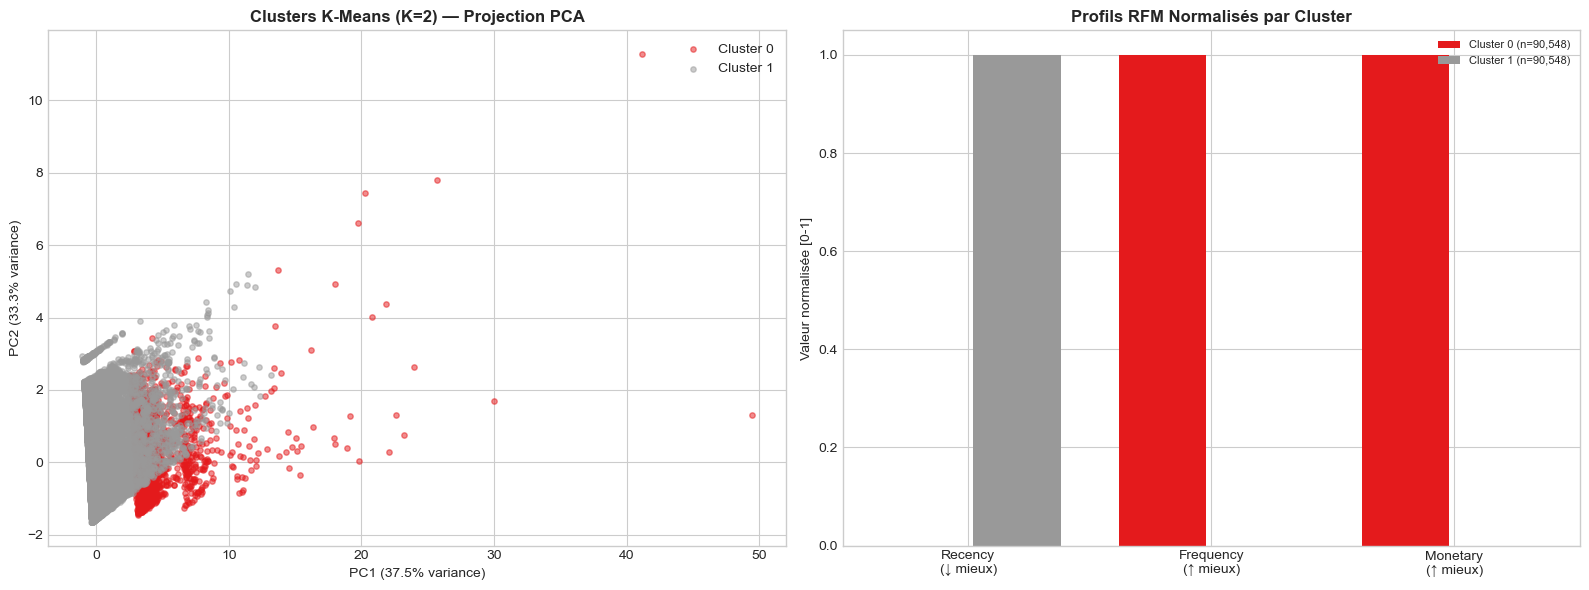


📊 PROFILS DES CLUSTERS :
                Recency  Frequency  Monetary
Cluster_KMeans                              
0              269.5700     2.1100  329.5100
1              287.6500     1.0000  160.1000

Taille des clusters :
Cluster_KMeans
0     2810
1    90548


In [96]:
# K-Means avec K optimal
km_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
rfm['Cluster_KMeans'] = km_final.fit_predict(rfm_scaled)

# PCA pour visualisation 2D
pca = PCA(n_components=2, random_state=42)
rfm_2d = pca.fit_transform(rfm_scaled)
rfm['PCA1'] = rfm_2d[:, 0]
rfm['PCA2'] = rfm_2d[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter PCA
colors = plt.cm.Set1(np.linspace(0, 1, k_optimal))
for i in range(k_optimal):
    mask = rfm['Cluster_KMeans'] == i
    axes[0].scatter(rfm.loc[mask,'PCA1'], rfm.loc[mask,'PCA2'],
                    c=[colors[i]], label=f'Cluster {i}', alpha=0.5, s=15)
axes[0].set_title(f'Clusters K-Means (K={k_optimal}) — Projection PCA', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].legend()

# Profils des clusters RFM
cluster_profile = rfm.groupby('Cluster_KMeans')[['Recency','Frequency','Monetary']].mean()
cluster_profile_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())

x = np.arange(3)
width = 0.8 / k_optimal
for i in range(k_optimal):
    offset = (i - k_optimal/2 + 0.5) * width
    axes[1].bar(x + offset, cluster_profile_norm.iloc[i], width*0.9,
                label=f'Cluster {i} (n={mask.sum():,})', color=colors[i])

axes[1].set_title('Profils RFM Normalisés par Cluster', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Recency\n(↓ mieux)', 'Frequency\n(↑ mieux)', 'Monetary\n(↑ mieux)'])
axes[1].set_ylabel('Valeur normalisée [0-1]')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 PROFILS DES CLUSTERS :')
print(cluster_profile.round(2).to_string())
print('\nTaille des clusters :')
print(rfm['Cluster_KMeans'].value_counts().sort_index().to_string())

In [94]:
# Labellisation des clusters
cluster_profile_sorted = cluster_profile.copy()
cluster_profile_sorted['Recency_inv'] = -cluster_profile_sorted['Recency']  # Récence inversée (faible = bien)

# Attribution automatique des labels
def label_cluster(row):
    if row['Recency'] <= cluster_profile['Recency'].quantile(0.25) and row['Frequency'] >= cluster_profile['Frequency'].quantile(0.75):
        return '🟢 Champions (récents & fréquents)'
    elif row['Recency'] >= cluster_profile['Recency'].quantile(0.75) and row['Monetary'] >= cluster_profile['Monetary'].quantile(0.5):
        return '🔴 À risque de churn (gros acheteurs absents)'
    elif row['Frequency'] <= cluster_profile['Frequency'].quantile(0.25):
        return '🟡 Nouveaux / One-shot'
    else:
        return '🔵 Clients réguliers'

cluster_labels = cluster_profile.apply(label_cluster, axis=1)
print('🏷️  LABELLISATION DES CLUSTERS :')
for i, label in cluster_labels.items():
    n = (rfm['Cluster_KMeans'] == i).sum()
    pct = n / len(rfm) * 100
    print(f'  Cluster {i}: {label} — {n:,} clients ({pct:.1f}%)')

🏷️  LABELLISATION DES CLUSTERS :
  Cluster 0: 🟢 Champions (récents & fréquents) — 2,810 clients (3.0%)
  Cluster 1: 🟡 Nouveaux / One-shot — 90,548 clients (97.0%)


In [98]:
# DBSCAN — Détection d'anomalies / outliers
# Sur un sous-ensemble (DBSCAN est lent sur grandes matrices)
rfm_sample = rfm_scaled[:5000]  # 5000 clients

dbscan = DBSCAN(eps=0.5, min_samples=10)
labels_dbscan = dbscan.fit_predict(rfm_sample)

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise       = (labels_dbscan == -1).sum()

print(f'🔎 DBSCAN Results (sous-échantillon 5000 clients) :')
print(f'   Clusters détectés : {n_clusters_db}')
print(f'   Points bruit (anomalies) : {n_noise} ({n_noise/len(rfm_sample)*100:.1f}%)')
print(f'   → Ces {n_noise} clients sont des outliers comportementaux à investiguer')

🔎 DBSCAN Results (sous-échantillon 5000 clients) :
   Clusters détectés : 2
   Points bruit (anomalies) : 108 (2.2%)
   → Ces 108 clients sont des outliers comportementaux à investiguer


### 3.7 Synthèse EDA — Insights Clés

In [101]:
print('=' * 70)
print('   📋 SYNTHÈSE EDA — INSIGHTS CLÉS POUR LA PRISE DE DÉCISION')
print('=' * 70)

insights = [
    (' CA Total',          f"R$ {df['total_payment'].sum():,.0f} sur {df['order_id'].nunique():,} commandes"),
    (' Ticket moyen',      f"R$ {df['total_payment'].mean():.2f} (médiane : R$ {df['total_payment'].median():.2f})"),
    (' Satisfaction moy.', f"{df_delivered['review_score'].mean():.2f} / 5 (std : {df_delivered['review_score'].std():.2f})"),
    (' Délai livraison',   f"{df_delivered['delivery_days'].mean():.1f} jours en moyenne"),
    (' Livraisons tardives',f"{df_delivered['is_late'].mean()*100:.1f}% des commandes livraison tardivement"),
    (' Repeat purchase',   f"{repeat_rate*100:.1f}% des clients rachètent → fort taux de churn ({churn_rate*100:.1f}%)"),
    (' Concentration SP',  f"São Paulo = {sp_rate:.1f}% des clients (biais géo important)"),
    (' Pic hebdo',         f"Lundi & mardi : pics de commandes"),
    (' Corrélation clé',  f"Retard livraison corrèle fortement avec baisse de satisfaction (p<0.001)"),
]

for k, v in insights:
    print(f'  {k:30s}: {v}')


   📋 SYNTHÈSE EDA — INSIGHTS CLÉS POUR LA PRISE DE DÉCISION
   CA Total                     : R$ 16,008,872 sur 99,441 commandes
   Ticket moyen                 : R$ 160.99 (médiane : R$ 105.29)
   Satisfaction moy.            : 4.16 / 5 (std : 1.28)
   Délai livraison              : 12.1 jours en moyenne
   Livraisons tardives          : 6.8% des commandes livraison tardivement
   Repeat purchase              : 3.1% des clients rachètent → fort taux de churn (96.9%)
   Concentration SP             : São Paulo = 42.0% des clients (biais géo important)
   Pic hebdo                    : Lundi & mardi : pics de commandes
   Corrélation clé              : Retard livraison corrèle fortement avec baisse de satisfaction (p<0.001)


## Export des Données Nettoyées

In [104]:
# Export
df_delivered.to_csv('olist_analytical_dataset.csv', index=False)
rfm.to_csv('olist_rfm_clusters.csv', index=False)
data_dictionary.to_csv('data_dictionary.csv', index=False)

print('✅ Fichiers exportés :')
print('   olist_analytical_dataset.csv — Dataset principal nettoyé & enrichi')
print('   olist_rfm_clusters.csv       — RFM + clusters K-Means')
print('   data_dictionary.csv          — Data Dictionary')
print(f'\n   Lignes dataset analytique : {len(df_delivered):,}')
print(f'   Colonnes                   : {len(df_delivered.columns)}')

✅ Fichiers exportés :
   olist_analytical_dataset.csv — Dataset principal nettoyé & enrichi
   olist_rfm_clusters.csv       — RFM + clusters K-Means
   data_dictionary.csv          — Data Dictionary

   Lignes dataset analytique : 96,478
   Colonnes                   : 25
